In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Dict, List, Tuple

from scipy.stats import binom
from scipy.optimize import curve_fit

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 14
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.fontset'] = 'cm'  
plt.rcParams['font.family'] = 'serif'


In [2]:
def energy_resolution_FWHM(sigma, mu):
    return sigma * 2 *np.sqrt(2 * np.log(2)) / mu

def gaussian(x, A, sigma, mu):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


# 1. Lectura de los datos en chunks

El documento es demasiado grande como para leerlo todo conjunto en memoria, de forma que se abre en secciones.

In [3]:
path ='/Users/pablovazquez/GALA_hole/build/geometric_hits_reflectantGALA_newPITCH_alternative_fullpeak.txt'

In [4]:
usecols = ['event_id', 'time_ns', 'vx_mm', 'vy_mm', 'vz_mm', 'nPhotons']

chunksize = 200_000
sampling = 500

# Primera pasada: rango temporal global y radio máximo por evento
time_min = np.inf
time_max = -np.inf
radius_by_event = {}
photons_generated_by_event = {}

for chunk in pd.read_csv(path, sep=r'\s+', usecols = usecols, chunksize = chunksize):
    chunk['vR_mm'] = np.sqrt(chunk['vx_mm']**2 + chunk['vy_mm']**2 + chunk['vz_mm']**2)
    time_min = min(time_min, chunk['time_ns'].min())
    time_max = max(time_max, chunk['time_ns'].max())

    grouped = chunk.groupby('event_id', sort=False)
    max_radius = grouped['vR_mm'].max()
    for event_id, r_max in max_radius.items():
        radius_by_event[event_id] = max(radius_by_event.get(event_id, 0.0), float(r_max))
    
    # Guardar fotones generados (tomar el primero de cada evento, ya que es el mismo para todo el evento)
    n_photons = grouped['nPhotons'].first()
    for event_id, n_phot in n_photons.items():
        photons_generated_by_event[event_id] = int(n_phot)

# Definir bins temporales globales
n_bins = int(np.ceil((time_max - time_min) / sampling))
bins = np.linspace(time_min, time_max, n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_width = bins[1] - bins[0]

# Segunda pasada: construir conteos por evento y bin
per_event_bin_counts = {}
photons_by_event = {}
hist = np.zeros(n_bins, dtype=int)

for chunk in pd.read_csv(path, sep=r'\s+', usecols=usecols, chunksize=chunksize):
    chunk['vR_mm'] = np.sqrt(chunk['vx_mm']**2 + chunk['vy_mm']**2 + chunk['vz_mm']**2)
    chunk['bin_index'] = np.digitize(chunk['time_ns'], bins) - 1
    chunk = chunk[(chunk['bin_index'] >= 0) & (chunk['bin_index'] < n_bins)]

    hist += np.histogram(chunk['time_ns'].to_numpy(), bins=bins)[0]

    for (event_id, bin_index), group in chunk.groupby(['event_id', 'bin_index'], sort=False):
        event_bins = per_event_bin_counts.setdefault(int(event_id), np.zeros(n_bins, dtype=int))
        n_hits = int(len(group))
        event_bins[int(bin_index)] += n_hits
        photons_by_event[event_id] = photons_by_event.get(event_id, 0) + n_hits

# Construir tabla resumida por evento para compatibilidad con el resto del notebook
sorted_event_ids = np.array(sorted(photons_by_event.keys()))
photons = np.array([photons_by_event[eid] for eid in sorted_event_ids])
radius = np.array([radius_by_event[eid] for eid in sorted_event_ids])
photons_generated = np.array([photons_generated_by_event.get(eid, 0) for eid in sorted_event_ids])

charge_binned = pd.DataFrame({
    'bin_center_ns': bin_centers,
    'n_hits': hist,
})

df_hits = pd.DataFrame({
    'event_id': sorted_event_ids,
    'photons': photons,
    'photons_generated': photons_generated,
    'radius': radius,
})

event_bin_rows = []
for event_id in sorted_event_ids:
    counts = per_event_bin_counts.get(int(event_id), np.zeros(n_bins, dtype=int))
    non_zero_bins = np.where(counts > 0)[0]
    for bin_index in non_zero_bins:
        event_bin_rows.append({
            'event_id': int(event_id),
            'bin_index': int(bin_index),
            'bin_center_ns': float(bin_centers[bin_index]),
            'n_hits': int(counts[bin_index]),
            'radius': float(radius_by_event[int(event_id)]),
        })

event_bins_df = pd.DataFrame(event_bin_rows)

print(f'Hits/eventos procesados en chunks: {len(sorted_event_ids):,}')
print(f'Rango temporal global: {time_min:.6f} ns a {time_max:.6f} ns')
print(f'Hits totales acumulados: {hist.sum():,}')
print(f'Bins temporales: {n_bins:,}')
event_bins_df.head()

TypeError: unsupported operand type(s) for ** or pow(): 'str' and 'int'

# 2. Cálculo de LCE

Definimos el número de fotones que se generan en el agujero de la GALA suponemos que una sigma del centro es lo que llega al agujero y tenemos en cuenta que para Xenon $W= 12.13\text{ eV}$ y el Kr genera $41.5 \text{ keV}$.

Cogemos los fotones generados en funcion de la distancia a la pared del agujero para entender los efectos de borde cerca de dicha pared

In [ ]:
photons = df_hits['photons'].to_numpy()
radius = df_hits['radius'].to_numpy()

In [ ]:
# Calcular LCE (Light Collection Efficiency)
df_hits['lce'] = df_hits['photons'] / df_hits['photons_generated']

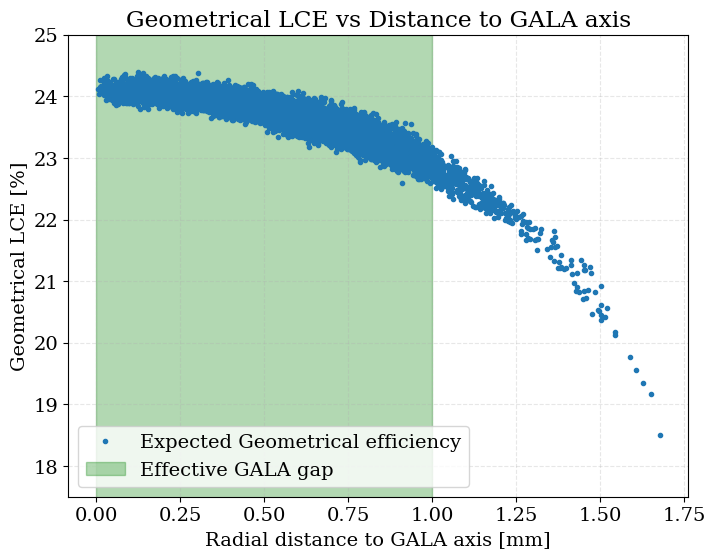

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(radius, df_hits.lce * 100, '.', label = 'Expected Geometrical efficiency');
plt.fill_between((0, 1),(25, 25), alpha=0.3, color = 'green', label = 'Effective GALA gap');

plt.title('Geometrical LCE vs Distance to GALA axis');
plt.xlabel('Radial distance to GALA axis [mm]');
plt.ylabel('Geometrical LCE [%]');

plt.grid(True, alpha=0.3, linestyle='--')

plt.ylim(17.5, 25)
plt.legend(loc = 'lower left');
plt.savefig('/Users/pablovazquez/GALA_hole/results/geometrical_lce_teflon.png')

Se observa, ya geométricamente aparece una pérdida de LCE por el ángulo sólido en funcion de cuanto te alejas del centro de la GALA (suponiendo reflexiones al 68% o 95% aparece una muy alta LCE).

# 3. Efectos de la electrónica

Aplico efectos de la electrónica (dark counts, crosstalk, pde y variación en la ganancia de los SiPM para poder entender como afectan estos a la medida de la resolución)

In [ ]:
pde = 0.23
crosstalk_prob = 0.07
dark_count_rate_hz = 860000
microcells = 4774
gain_sigma_rel = 0.12
acquisition_window_ns = 1000.0

Dichos efectos de la electrónica se aplican por bin temporal.

In [ ]:
def compute_pde_bin(event_bins_df, prob_pde=pde, prob_crosstalk=crosstalk_prob,
                    dark_noise=dark_count_rate_hz, gain_sigma_rel=gain_sigma_rel,
                    acquisition_window_ns=acquisition_window_ns,
                    rng=None):
    """
    Procesa los bins temporales de un evento y aplica todas las etapas de electrónica.

    Cada fila de `event_bins_df` representa un bin temporal del evento con:
    - event_id
    - bin_index
    - bin_center_ns
    - n_hits
    - radius

    Retorna una fila por bin con:
    - n_pde
    - n_crosstalk
    - n_dark
    - charge_pe
    """

    if rng is None:
        rng = np.random.default_rng()

    if event_bins_df.empty or 'n_hits' not in event_bins_df.columns:
        return pd.DataFrame(columns=[
            'event_id', 'bin_index', 'bin_center_ns', 'radius', 'n_hits',
            'n_pde', 'n_crosstalk', 'n_dark', 'n_after_ct', 'n_after_dark', 'charge_pe'
        ])

    rows = []
    event_id = int(event_bins_df['event_id'].iloc[0])
    radius = float(event_bins_df['radius'].iloc[0])
    dark_mean = dark_noise * acquisition_window_ns * 1e-9

    for _, row in event_bins_df.sort_values('bin_index').iterrows():
        n_hits = int(row['n_hits'])
        bin_index = int(row['bin_index'])
        bin_center_ns = float(row['bin_center_ns'])

        n_pde = min(int(rng.binomial(n_hits, prob_pde)), microcells)
        n_crosstalk = int(rng.binomial(n_pde, prob_crosstalk))
        n_after_ct = min(n_pde + n_crosstalk, microcells)
        n_dark = int(rng.poisson(dark_mean))
        n_after_dark = min(n_after_ct + n_dark, microcells)

        sigma_gain = gain_sigma_rel * np.sqrt(max(n_after_dark, 1))
        charge_pe = float(n_after_dark + rng.normal(0.0, sigma_gain))
        if charge_pe < 0.0:
            charge_pe = 0.0

        rows.append({
            'event_id': event_id,
            'bin_index': bin_index,
            'bin_center_ns': bin_center_ns,
            'radius': radius,
            'n_hits': n_hits,
            'n_pde': n_pde,
            'n_crosstalk': n_crosstalk,
            'n_dark': n_dark,
            'n_after_ct': n_after_ct,
            'n_after_dark': n_after_dark,
            'charge_pe': charge_pe,
        })

    return pd.DataFrame(rows)

In [ ]:
event_bins_df

,event_id,bin_index,bin_center_ns,n_hits,radius
0,0,2,8795.378611,1,0.202776
1,0,3,9287.438056,23,0.202776
2,0,4,9779.497500,141,0.202776
3,0,5,10271.556944,793,0.202776
4,0,6,10763.616389,2705,0.202776
...,...,...,...,...,...
147215,9999,12,13715.973056,2199,0.328817
147216,9999,13,14208.032500,566,0.328817
147217,9999,14,14700.091944,115,0.328817
147218,9999,15,15192.151389,7,0.328817


In [ ]:
rng_electronics = np.random.default_rng()
resultados_electronica = []

for event_id, event_bins_df in event_bins_df.groupby('event_id', sort=True):
    event_result = compute_pde_bin(
        event_bins_df,
        prob_pde=pde,
        prob_crosstalk=crosstalk_prob,
        dark_noise=dark_count_rate_hz,
        gain_sigma_rel=gain_sigma_rel,
        acquisition_window_ns=acquisition_window_ns,
        rng=rng_electronics,
    )
    resultados_electronica.append(event_result)

charge_binned_electronica = pd.concat(resultados_electronica, ignore_index=True)
print(f'Eventos procesados: {charge_binned_electronica["event_id"].nunique():,}')
print(f'Filas bin-evento procesadas: {len(charge_binned_electronica):,}')
charge_binned_electronica.head()

Eventos procesados: 10,000
Filas bin-evento procesadas: 147,220


,event_id,bin_index,bin_center_ns,radius,n_hits,n_pde,n_crosstalk,n_dark,n_after_ct,n_after_dark,charge_pe
0,0,2,8795.378611,0.202776,1,0,0,1,0,1,0.872756
1,0,3,9287.438056,0.202776,23,9,0,0,9,9,9.275595
2,0,4,9779.497500,0.202776,141,43,3,0,46,46,44.650166
3,0,5,10271.556944,0.202776,793,154,8,0,162,162,162.419264
4,0,6,10763.616389,0.202776,2705,656,56,0,712,712,716.875414


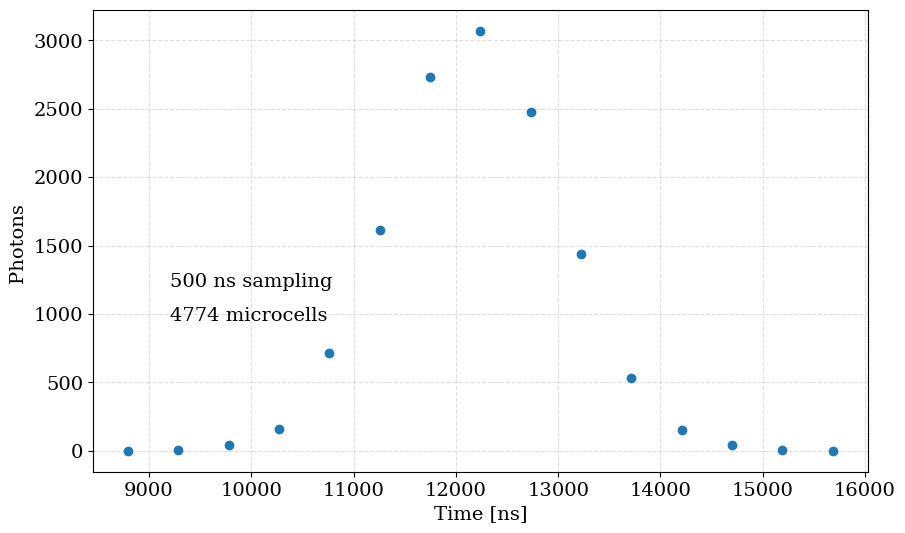

In [ ]:
plt.plot(charge_binned_electronica[charge_binned_electronica.event_id==0].bin_center_ns, charge_binned_electronica[charge_binned_electronica.event_id==0]['charge_pe'], 'o');
plt.xlabel('Time [ns]');
plt.ylabel('Photons ');
plt.annotate('500 ns sampling', xy = (9200, 1200), )
plt.annotate('4774 microcells', xy = (9200, 950))
plt.grid(True, alpha = 0.4, linestyle = '--')
plt.savefig('/Users/pablovazquez/GALA_hole/results/opaque_500ns_sampling_signal.png')

In [ ]:
# Carga total por evento (sumando bins)
event_summary = (
    charge_binned_electronica
    .groupby('event_id', as_index=False)
    .agg(
        radius=('radius', 'first'),
        charge_pe=('charge_pe', 'sum'),
        n_hits=('n_hits', 'sum'),
        n_pde=('n_pde', 'sum'),
        n_crosstalk=('n_crosstalk', 'sum'),
        n_dark=('n_dark', 'sum'),
    )
)

charge_collection = event_summary['charge_pe'].to_list()
charge_collection_center = event_summary.loc[event_summary['radius'] < 0.85, 'charge_pe'].to_list()

print(f'Eventos totales: {len(charge_collection)}')
print(f'Eventos con radius < 0.7 mm: {len(charge_collection_center)}')

Eventos totales: 10000
Eventos con radius < 0.7 mm: 8959


In [ ]:
event_summary

,event_id,radius,charge_pe,n_hits,n_pde,n_crosstalk,n_dark
0,0,0.202776,12988.796936,52117,12149,823,10
1,1,0.628003,12556.800410,50691,11749,781,14
2,2,0.501045,12713.413792,51751,11842,851,9
3,3,0.703441,12454.891167,50305,11630,827,9
4,4,0.515965,13081.358768,52658,12227,881,13
...,...,...,...,...,...,...,...
9995,9995,0.446229,12754.348350,51324,11891,851,15
9996,9996,0.483488,12458.573823,51873,11635,821,20
9997,9997,0.671735,12917.316939,51872,12018,883,12
9998,9998,0.891647,12082.011455,49282,11292,775,7


In [ ]:
event_summary.charge_pe/df_hits.photons_generated

0       0.059932
1       0.058442
2       0.058558
3       0.057923
4       0.059465
          ...   
9995    0.059347
9996    0.056772
9997    0.058806
9998    0.056263
9999    0.058871
Length: 10000, dtype: float64

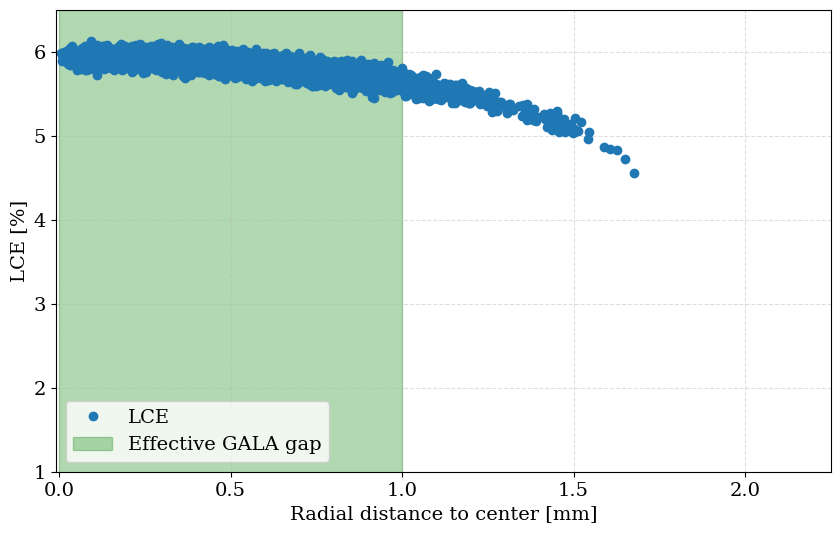

In [ ]:
plt.plot(radius, event_summary.charge_pe/df_hits.photons_generated*100, 'o', label = 'LCE');
plt.xlabel('Radial distance to center [mm]');
plt.ylabel('LCE [%]');
plt.ylim(1, 6.5)
plt.xlim(-0.01, 2.25)
plt.grid(True, alpha = 0.4, linestyle='--');
plt.fill_between((0, 1),(6.5, 6.5), alpha=0.3, color = 'green', label = 'Effective GALA gap');
plt.legend(loc = 'lower left');
plt.savefig('/Users/pablovazquez/GALA_hole/results/total_lce_teflon.png')

In [ ]:
counts, bins = np.histogram(charge_collection_center, bins = 20)
bincents = (bins[:-1] + bins[1:]) / 2

In [ ]:
xplot = np.linspace(bincents[0], bincents[-1], 1000)

In [ ]:
popt, pcov = curve_fit(gaussian, bincents, counts, p0 = (400, 200, 12500))

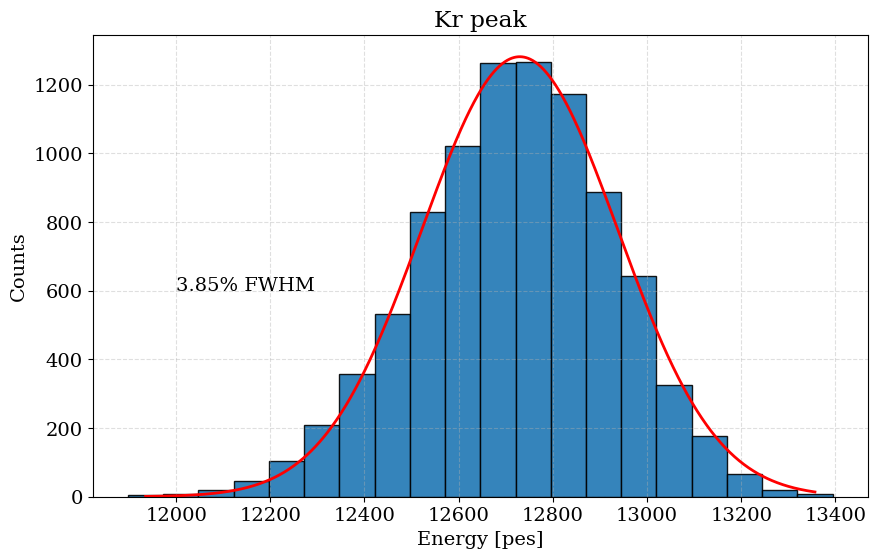

In [ ]:
plt.hist(charge_collection_center, bins =20, alpha = .9, edgecolor = 'black');
plt.plot(xplot, gaussian(xplot, *popt), 'r-', linewidth=2);
plt.annotate(f'{energy_resolution_FWHM(popt[1], popt[2])*100:.2f}% FWHM', xy = (12000, 600))
plt.xlabel('Energy [pes]');
plt.ylabel('Counts');
plt.grid(True, alpha = 0.4, linestyle='--');
plt.title('Kr peak');
plt.savefig('/Users/pablovazquez/GALA_hole/results/Energy_resolution_teflon.png')